## Case Study

### Import Pacages

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

### Loading DB

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/clustering/travel.csv', parse_dates=['date_time', 'srch_ci', 'srch_co'])
df.head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_children_cnt,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster
0,2014-11-03 16:02:00,24,2,77,871,36643,456.1151,792280,0,1,...,0,1,8286,1,0,1,0,63,1258,68
1,2013-03-13 19:25:00,11,3,205,135,38749,232.4737,961995,0,0,...,0,1,1842,3,0,1,2,198,786,37
2,2014-10-13 13:20:00,2,3,66,314,48562,4468.2720,495669,0,1,...,0,1,8746,1,0,1,6,105,29,22
3,2013-11-05 10:40:00,11,3,205,411,52752,171.6021,106611,0,0,...,0,1,6210,3,1,1,2,198,1234,42
4,2014-06-10 13:34:00,2,3,66,174,50644,NaN,596177,0,0,...,1,1,12812,5,0,1,2,50,368,83


In [4]:
df.to_csv('../data/clustering/travel.csv')

#### Dataframe Size

In [5]:
print("Rows:    ", df.shape[0])
print("Columns: ", df.shape[1])

Rows:     100000
Columns:  24


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 24 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   date_time                  100000 non-null  datetime64[us]
 1   site_name                  100000 non-null  int64         
 2   posa_continent             100000 non-null  int64         
 3   user_location_country      100000 non-null  int64         
 4   user_location_region       100000 non-null  int64         
 5   user_location_city         100000 non-null  int64         
 6   orig_destination_distance  63915 non-null   float64       
 7   user_id                    100000 non-null  int64         
 8   is_mobile                  100000 non-null  int64         
 9   is_package                 100000 non-null  int64         
 10  channel                    100000 non-null  int64         
 11  srch_ci                    99878 non-null   datetime64[us]
 12  

In [7]:
df.isnull().sum()

date_time                        0
site_name                        0
posa_continent                   0
user_location_country            0
user_location_region             0
user_location_city               0
orig_destination_distance    36085
user_id                          0
is_mobile                        0
is_package                       0
channel                          0
srch_ci                        122
srch_co                        122
srch_adults_cnt                  0
srch_children_cnt                0
srch_rm_cnt                      0
srch_destination_id              0
srch_destination_type_id         0
is_booking                       0
cnt                              0
hotel_continent                  0
hotel_country                    0
hotel_market                     0
hotel_cluster                    0
dtype: int64

### Correlation Matrix

Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

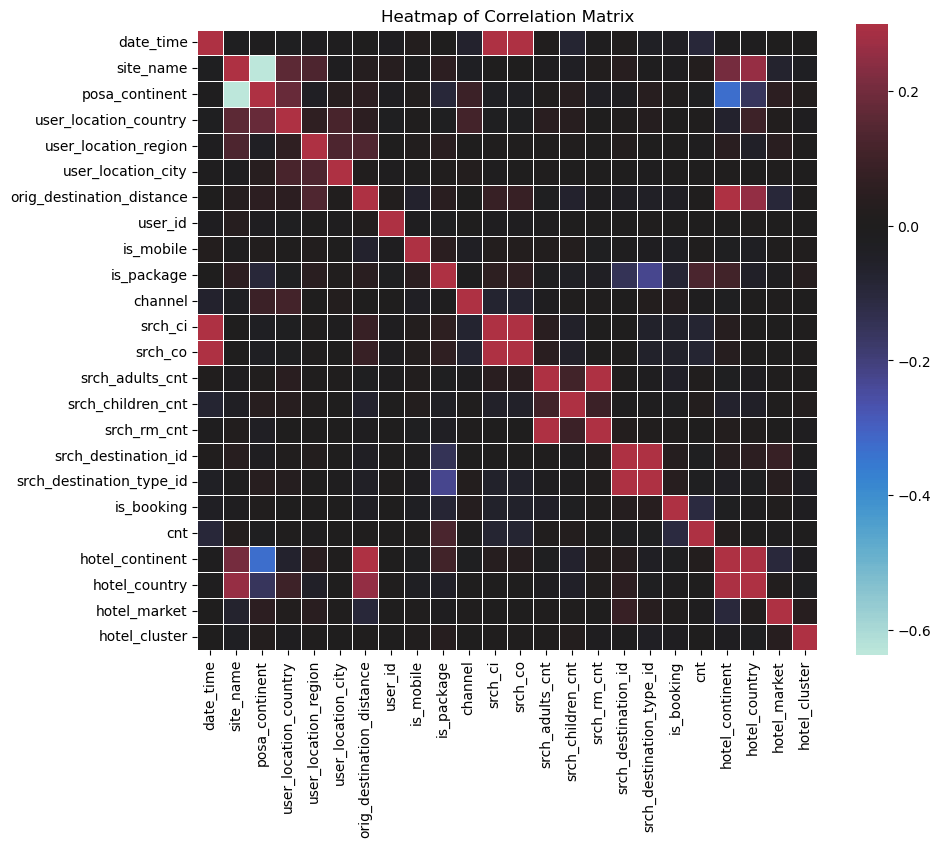

In [9]:
corr = df.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(corr, xticklabels=corr.columns.values, yticklabels=corr.columns.values, vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title("Heatmap of Correlation Matrix")

### Distributions

array([[<Axes: title={'center': 'channel'}>,
        <Axes: title={'center': 'is_booking'}>,
        <Axes: title={'center': 'is_mobile'}>],
       [<Axes: title={'center': 'orig_destination_distance'}>,
        <Axes: title={'center': 'srch_rm_cnt'}>,
        <Axes: title={'center': 'srch_adults_cnt'}>],
       [<Axes: title={'center': 'srch_children_cnt'}>, <Axes: >,
        <Axes: >]], dtype=object)

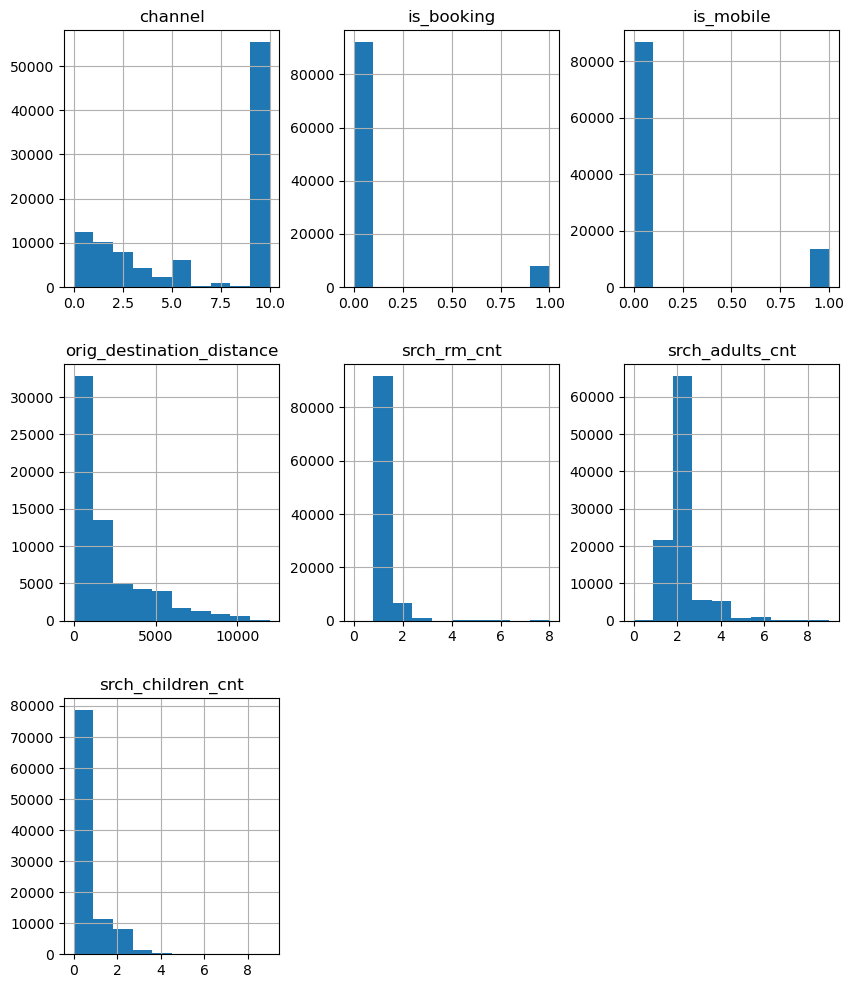

In [10]:
df[['channel', 'is_booking', 'is_mobile', 'orig_destination_distance', 'srch_rm_cnt', 'srch_adults_cnt', 'srch_children_cnt']].hist(figsize=(10, 12))

#### is_booking

In [13]:
booking_count_per_user = df.groupby('user_id')['is_booking'].agg(num_of_bookings='count').reset_index()
booking_count_per_user.groupby('num_of_bookings')['user_id'].agg('count')

num_of_bookings
1    79189
2     8423
3     1065
4      161
5       24
6        1
Name: user_id, dtype: int64

### Merge with the Original Data

In [15]:
df = df.merge(df.groupby('user_id')['is_booking'].agg(['count']).reset_index())
df.head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,count
0,2014-11-03 16:02:00,24,2,77,871,36643,456.1151,792280,0,1,...,1,8286,1,0,1,0,63,1258,68,2
1,2013-03-13 19:25:00,11,3,205,135,38749,232.4737,961995,0,0,...,1,1842,3,0,1,2,198,786,37,1
2,2014-10-13 13:20:00,2,3,66,314,48562,4468.2720,495669,0,1,...,1,8746,1,0,1,6,105,29,22,1
3,2013-11-05 10:40:00,11,3,205,411,52752,171.6021,106611,0,0,...,1,6210,3,1,1,2,198,1234,42,2
4,2014-06-10 13:34:00,2,3,66,174,50644,NaN,596177,0,0,...,1,12812,5,0,1,2,50,368,83,1


### Logical Check

In [16]:
pd.crosstab(df['srch_adults_cnt'], df['srch_children_cnt'])

srch_children_cnt,0,1,2,3,4,5,6,7,8,9
srch_adults_cnt,,,,,,,,,,
0,174,2,3,2,0,0,0,0,0,0
1,18749,2137,523,117,11,1,9,1,2,0
2,50736,7093,6529,972,208,14,7,1,0,0
3,3645,1131,469,131,27,5,2,2,0,2
4,3933,690,494,77,83,9,4,0,0,0
5,535,131,41,20,6,4,2,0,0,0
6,669,73,53,28,18,13,7,0,0,0
7,99,20,5,8,6,3,0,0,0,0
8,183,12,13,2,6,1,3,2,2,1


In [17]:
df[(df['srch_adults_cnt'] == 0) & (df['srch_children_cnt'] == 0)].head()

,date_time,site_name,posa_continent,user_location_country,user_location_region,user_location_city,orig_destination_distance,user_id,is_mobile,is_package,...,srch_rm_cnt,srch_destination_id,srch_destination_type_id,is_booking,cnt,hotel_continent,hotel_country,hotel_market,hotel_cluster,count
115,2014-10-07 14:43:00,2,3,66,293,52284,NaN,909952,0,1,...,1,8250,1,0,1,2,50,628,1,1
496,2013-06-15 19:12:00,29,1,52,40,29080,NaN,150434,0,1,...,2,25408,6,0,2,6,15,1534,46,1
1261,2014-10-26 10:20:00,2,3,66,220,22648,5148.4830,588617,1,1,...,1,8746,1,0,1,6,105,29,78,1
1428,2014-11-16 10:21:00,2,3,66,174,53801,1638.7472,207522,1,1,...,1,8810,1,0,1,4,8,1532,52,1
1539,2014-12-28 19:16:00,2,3,66,363,31138,1526.8518,938404,0,1,...,1,8277,1,0,1,2,50,412,9,1


In [21]:
df.drop(df[df['srch_adults_cnt'] + df['srch_children_cnt'] == 0].index, inplace=True,)

### Dates

In [22]:
df['date'] = pd.to_datetime(df['date_time'].apply(lambda x: x.date()))

In [23]:
df[df['srch_co'] < df['srch_ci']][['srch_co', 'srch_ci']].shape

(2, 2)

In [24]:
df[df['srch_ci'] < df['date']][['srch_ci', 'date']].shape

(25, 2)

In [25]:
### Feature Enrichment

In [27]:
def duration(row, start, end):
    delta = (row[end] - row[start]) / np.timedelta64(1, 'D')
    if delta <= 0:
        return np.nan
    else:
        return delta

In [28]:
df['duration'] =df.apply(duration, args=('srch_ci', 'srch_co'), axis=1)

In [29]:
df['days_in_advance'] = df.apply(duration, args=('date', 'srch_ci'), axis=1)

In [30]:
(df
 .groupby('channel')['is_booking']
 .agg(booking_rate='mean', num_of_bookings='count')
 .reset_index()
 .sort_values(by='channel'))

,channel,booking_rate,num_of_bookings
0,0,0.072184,12482
1,1,0.069568,10249
2,2,0.060583,7824
3,3,0.060482,4398
4,4,0.120438,2192
5,5,0.094533,6146
6,6,0.068323,161
7,7,0.043263,809
8,8,0.051852,270
9,9,0.085365,55280


### Clustering

#### Feature Selection

In [32]:
features_to_explore = ['duration', 'days_in_advance', 'orig_destination_distance', 'is_mobile', 'is_package', 'srch_adults_cnt', 'srch_children_cnt', 'srch_rm_cnt']

df_clustering = df[features_to_explore + ['user_location_city']]
df_clustering_groups = (df_clustering
                        .groupby('user_location_city')
                        .mean()
                        .reset_index()
                        .dropna(axis=0))

#### Standardize our Data

In [34]:
from sklearn import preprocessing

df_clustering_std = df_clustering_groups.copy()
df_clustering_std[features_to_explore] = preprocessing.scale(df_clustering_std[features_to_explore])
df_clustering_std.head()

,user_location_city,duration,days_in_advance,orig_destination_distance,is_mobile,is_package,srch_adults_cnt,srch_children_cnt,srch_rm_cnt
0,0,-0.685258,0.447140,0.314747,-0.619979,-0.023150,-0.511139,-0.704997,-0.331661
2,3,0.564013,0.651185,1.020233,-0.347544,0.125553,-0.207376,0.201429,-0.331661
3,7,5.164984,-0.007237,2.600430,-0.619979,2.504801,-0.113910,-0.704997,-0.331661
5,14,1.752343,-0.500401,2.195332,-0.619979,-0.865800,-0.113910,0.739619,-0.331661
8,21,0.777303,-0.594601,0.221515,-0.619979,0.819500,-0.908368,1.221158,-0.331661


#### K-means

In [35]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, max_iter=300, random_state=123)
df_clustering_std["cluster"] = km.fit_predict(df_clustering_std[features_to_explore])
df_clustering_std.head()

c:\Users\User\miniconda3\envs\vav\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,user_location_city,duration,days_in_advance,orig_destination_distance,is_mobile,is_package,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,cluster
0,0,-0.685258,0.447140,0.314747,-0.619979,-0.023150,-0.511139,-0.704997,-0.331661,2
2,3,0.564013,0.651185,1.020233,-0.347544,0.125553,-0.207376,0.201429,-0.331661,1
3,7,5.164984,-0.007237,2.600430,-0.619979,2.504801,-0.113910,-0.704997,-0.331661,0
5,14,1.752343,-0.500401,2.195332,-0.619979,-0.865800,-0.113910,0.739619,-0.331661,1
8,21,0.777303,-0.594601,0.221515,-0.619979,0.819500,-0.908368,1.221158,-0.331661,0


### PCA

In [37]:
from sklearn import decomposition

pca = decomposition.PCA(n_components=2, whiten=True)
pca_results = pca.fit_transform(df_clustering_std[features_to_explore])
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print(f"Cumulative Variance: {cumulative_variance}")

Cumulative Variance: [0.21982537 0.40991447]


In [38]:
df_clustering_std['x'] = pca_results[:, 0]
df_clustering_std['y'] = pca_results[:, 1]
df_clustering_std.head()

,user_location_city,duration,days_in_advance,orig_destination_distance,is_mobile,is_package,srch_adults_cnt,srch_children_cnt,srch_rm_cnt,cluster,x,y
0,0,-0.685258,0.447140,0.314747,-0.619979,-0.023150,-0.511139,-0.704997,-0.331661,2,0.095833,-0.521284
2,3,0.564013,0.651185,1.020233,-0.347544,0.125553,-0.207376,0.201429,-0.331661,1,0.929255,-0.156800
3,7,5.164984,-0.007237,2.600430,-0.619979,2.504801,-0.113910,-0.704997,-0.331661,0,3.937174,-0.238704
5,14,1.752343,-0.500401,2.195332,-0.619979,-0.865800,-0.113910,0.739619,-0.331661,1,1.051649,-0.087671
8,21,0.777303,-0.594601,0.221515,-0.619979,0.819500,-0.908368,1.221158,-0.331661,0,0.425947,-0.558020


## Fake Data

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

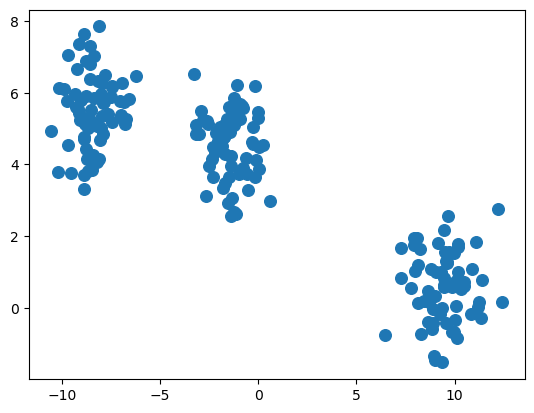

In [45]:
X, Y = make_blobs(n_samples=200, n_features=2, centers=3, cluster_std=1, shuffle=True, random_state=7)
plt.scatter(X[:, 0], X[:, 1], marker='o', s=70)
plt.show()

### K-Means

c:\Users\User\miniconda3\envs\vav\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


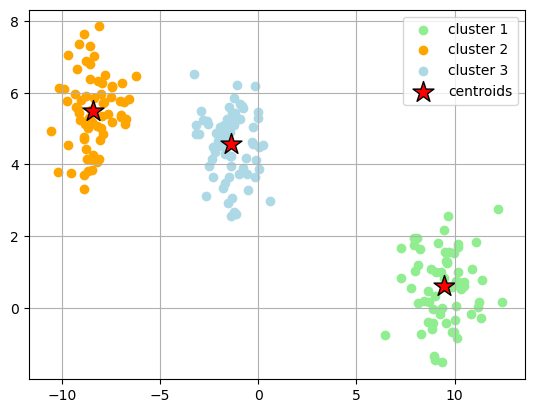

In [47]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3, max_iter=500)
y_km = km.fit_predict(X)

plt.scatter(X[y_km == 0, 0], X[y_km ==0, 1], c='lightgreen', label='cluster 1')
plt.scatter(X[y_km == 1, 0], X[y_km == 1, 1], c='orange', label='cluster 2')
plt.scatter(X[y_km == 2, 0], X[y_km ==2, 1], c='lightblue', label='cluster 3')

plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], s=250, marker='*', c='red', edgecolor='black', label='centroids')
plt.legend(scatterpoints=1)
plt.grid()

### Elbow Method

c:\Users\User\miniconda3\envs\vav\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\miniconda3\envs\vav\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\miniconda3\envs\vav\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\miniconda3\envs\vav\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is k

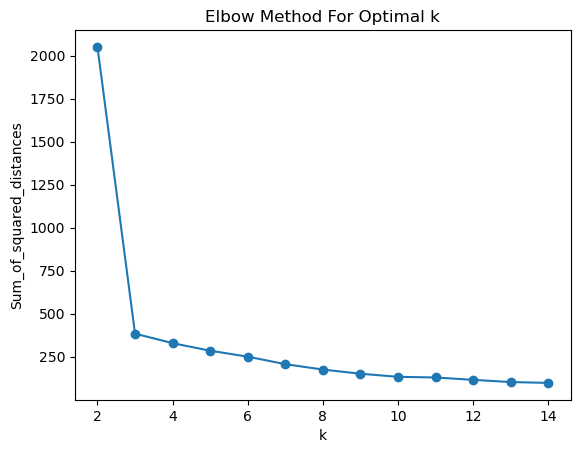

In [49]:
Sum_of_squared_distances = []
K = range(2, 15)
for k in K:
    km = KMeans(n_clusters=k, init='random', n_init=10, max_iter=500, tol=1e-04, random_state=0)
    km = km.fit(X)
    Sum_of_squared_distances.append(km.inertia_)
    
plt.plot(K, Sum_of_squared_distances, marker='o')
plt.xlabel('k')
plt.ylabel('Sum_of_squared_distances')
plt.title('Elbow Method For Optimal k')
plt.show()

### Silhouette Analysis

In [50]:
from sklearn.metrics import silhouette_score

for n_clusters in range(2, 10):
    cluster = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = cluster.fit_predict(X)
    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusterd =", n_clusters, "The average silhouette_score is: {:4f}".format(silhouette_avg))
    

For n_clusterd = 2 The average silhouette_score is: 0.748643
For n_clusterd = 3 The average silhouette_score is: 0.785358
For n_clusterd = 4 The average silhouette_score is: 0.641820
For n_clusterd = 5 The average silhouette_score is: 0.461010
For n_clusterd = 6 The average silhouette_score is: 0.477107
For n_clusterd = 7 The average silhouette_score is: 0.325233
For n_clusterd = 8 The average silhouette_score is: 0.478205
For n_clusterd = 9 The average silhouette_score is: 0.361148


c:\Users\User\miniconda3\envs\vav\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\miniconda3\envs\vav\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\miniconda3\envs\vav\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\User\miniconda3\envs\vav\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is k